# Layer1; 32; 3x3; maxpool

In [1]:
import os
print(os.environ.get("LD_LIBRARY_PATH"))

/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cublas/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cuda_runtime/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cudnn/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cufft/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cusolver/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cusparse/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/nccl/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cublas/lib:/mnt/c/Users/ASUS/Documents/GitHub/CNN-RNN-LSTM-Scratch/tf-gpu/lib/python3.10/site-packages/nvidia/cuda_runtime/li

## Import Libraries

In [2]:
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import f1_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
tf.test.is_built_with_cuda()

I0000 00:00:1778589085.376025    3374 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


True

## Config

In [3]:
TRAIN_DIR  = '../../data/intel/seg_train'
VAL_DIR    = '../../data/intel/seg_test'
TEST_DIR   = '../../data/intel/seg_pred'
MODEL_DIR  = '../../data/models/cnn'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 64
EPOCHS      = 10
NUM_CLASSES = 6
LR          = 1e-4
VAL_SPLIT   = 0.2

## Import Dataset

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = keras.layers.Rescaling(1.0 / 255.0)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

train_ds = (
    train_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

train_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
val_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=1, label_mode="int"
))
test_count = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=1, label_mode="int", shuffle=False
))

print("Kelas      :", {name: i for i, name in enumerate(class_names)})
print(f"Train      : {train_count} gambar")
print(f"Validation : {val_count} gambar")
print(f"Test       : {test_count} gambar")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1778589238.547050    3374 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Kelas      : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train      : 11228 gambar
Validation : 2806 gambar
Test       : 3000 gambar


## CNN Model Baseline Architecture

In [5]:
MODEL_NAME = 'Layer-1-32-3x3-maxpool'
model = keras.Sequential([
    keras.layers.Input(shape=IMG_SIZE + (3,), name='input'),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv2s_1'),
    keras.layers.MaxPooling2D((2, 2), name='maxpool_1'),
    keras.layers.Flatten(name='flatten'),
    keras.layers.Dense(128, activation='relu', name='dense_1'),
    keras.layers.Dense(6, activation='softmax', name='output'),
], name=MODEL_NAME)
model.summary()

Model: "Layer-1-32-3x3-maxpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2s_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,431,494 (85.57 MB)

 Trainable params: 22,431,494 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

## Compilation and Training

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callback = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=f'../../data/models/cnn/{MODEL_NAME}.h5',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1
)

Epoch 1/10


I0000 00:00:1778589303.644239    4293 shuffle_dataset_op.cc:453] ShuffleDatasetV3:21: Filling up shuffle buffer (this may take a while): 86 of 1000
I0000 00:00:1778589315.281986    4293 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1778589315.391229    3990 service.cc:153] XLA service 0x7b8434031f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778589315.393118    3990 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778589315.883092    3990 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778589316.454434    3990 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778589316.564998    3990 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35531__.21
I0000 00:00:1778589321.588500    4332

155/176 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4139 - loss: 1.8036

I0000 00:00:1778589334.118612    3990 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35531__.21


175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4252 - loss: 1.7508

...

176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.7246 - loss: 0.7838 - val_accuracy: 0.8100 - val_loss: 0.5947
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7540 - loss: 0.7038
Epoch 4: val_loss improved from 0.59474 to 0.47262, saving model to ../../data/models/cnn/Layer-1-32-3x3-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.7634 - loss: 0.6888 - val_accuracy: 0.8749 - val_loss: 0.4726
Epoch 5/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8127 - loss: 0.5988
Epoch 5: val_loss improved from 0.47262 to 0.45194, saving model to ../../data/models/cnn/Layer-1-32-3x3-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.8040 - loss: 0.6048 - val_accuracy: 0.8838 - val_loss: 0.4519
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8337 - loss: 0.5380
Epoch 6: val_loss did not improve from 0.45194
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8300 - loss: 0.5376 - val_accuracy: 0.8225 - val_loss: 0.5714
Epoch 7/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8487 - loss: 0.4974
Epoch 7: val_loss improved from 0.45194 to 0.35865, saving model to ../../data/models/cnn/Layer-1-32-3x3-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.8497 - loss: 0.4907 - val_accuracy: 0.9130 - val_loss: 0.3586
Epoch 8/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8754 - loss: 0.4367
Epoch 8: val_loss did not improve from 0.35865
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8736 - loss: 0.4314 - val_accuracy: 0.8721 - val_loss: 0.4283
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8916 - loss: 0.3882
Epoch 9: val_loss improved from 0.35865 to 0.32368, saving model to ../../data/models/cnn/Layer-1-32-3x3-maxpool.h5


176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.8890 - loss: 0.3909 - val_accuracy: 0.9166 - val_loss: 0.3237
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9099 - loss: 0.3531
Epoch 10: val_loss did not improve from 0.32368
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9062 - loss: 0.3509 - val_accuracy: 0.9016 - val_loss: 0.3491
Restoring model weights from the end of the best epoch: 9.


## Evaluation

In [7]:
y_pred_proba = model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step
Macro F1 Score: 0.7481


## Plot

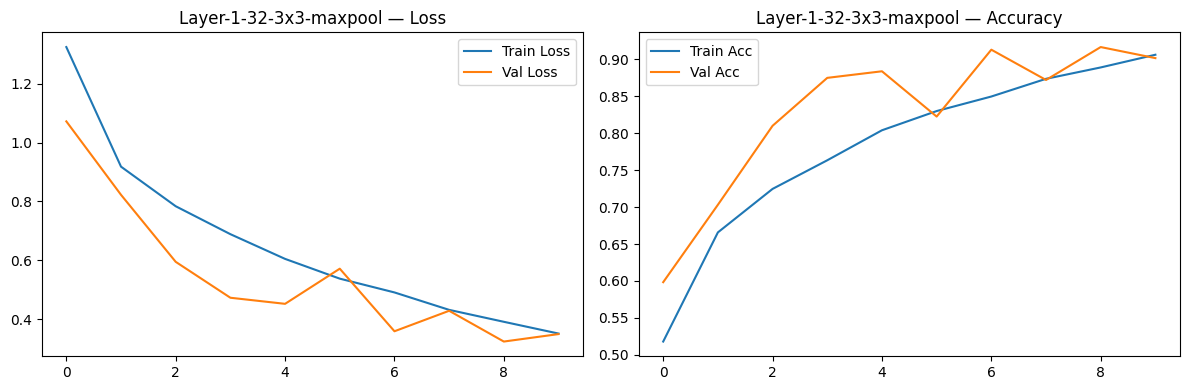

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train Loss')
ax1.plot(history.history['val_loss'],     label='Val Loss')
ax1.set_title(f'{MODEL_NAME} — Loss'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title(f'{MODEL_NAME} — Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, f'{MODEL_NAME}_curve.png'), dpi=100)
plt.show()